# From Pilot to Payoff - 04: Q3 - Firm-Level Drivers of Advanced Adoption

Q3: After controlling for country/region context, industry, company size, and time, which representative firm-level drivers from capability, investment, and governance/risk blocks are most strongly associated with advanced AI adoption after checking multicollinearity and model contribution?

## Setup and data preparation

*Re-runs the shared imports, data loading, feature engineering, and standardisation so the notebook is self-contained. Identical across the analysis modules; see `01_setup_and_data_prep.ipynb` for the documented version with the data dictionary.*

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats

import statsmodels.api as sm
from statsmodels.formula.api import ols, logit
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupShuffleSplit

import matplotlib.pyplot as plt
import seaborn as sns

# Folder for saving generated figures.
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)


In [2]:
company = pd.read_csv('ai_company_adoption.csv')
country_index = pd.read_csv('country_ai_index.csv')
industry_summary = pd.read_csv('ai_industry_summary.csv')

print('Dataset shapes')
print(f'company adoption: {company.shape[0]:,} rows x {company.shape[1]:,} columns')
print(f'country index:    {country_index.shape[0]:,} rows x {country_index.shape[1]:,} columns')
print(f'industry summary: {industry_summary.shape[0]:,} rows x {industry_summary.shape[1]:,} columns')

company.head(3)


Dataset shapes
company adoption: 150,000 rows x 43 columns
country index:    30 rows x 8 columns
industry summary: 9 rows x 8 columns


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation


In [3]:
# Feature engineering and merge.
quarter_map = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
company = company.copy()
company['quarter_num'] = company['quarter'].map(quarter_map)
company['advanced_adoption'] = company['ai_adoption_stage'].isin(['partial', 'full']).astype(int)
company['net_jobs_created'] = company['jobs_created'] - company['jobs_displaced']
company['net_jobs_per_100_employees'] = company['net_jobs_created'] / company['num_employees'] * 100
company['reskilling_rate_per_100_employees'] = company['reskilled_employees'] / company['num_employees'] * 100

# Log transform for the skewed investment variable. log1p handles zero values safely.
company['log_ai_investment_per_employee'] = np.log1p(company['ai_investment_per_employee'])

country_model = country_index.drop(columns=['region'])
country_model['log_gdp_per_capita'] = np.log1p(country_model['gdp_per_capita'])
country_model['log_ai_patent_filings_2024'] = np.log1p(country_model['ai_patent_filings_2024'])

df = company.merge(country_model, on='country', how='left')

# Latest observation per company for robustness checks.
latest_obs = (df.sort_values(['company_id', 'survey_year', 'quarter_num'])
                .groupby('company_id', as_index=False)
                .tail(1)
                .reset_index(drop=True))

# Digital maturity tertiles for interaction models.
df['digital_maturity_tertile'] = pd.qcut(
    df['digital_maturity_index'], q=3, labels=['Low', 'Medium', 'High']
)
latest_obs['digital_maturity_tertile'] = pd.qcut(
    latest_obs['digital_maturity_index'], q=3, labels=['Low', 'Medium', 'High']
)

merge_check = df[['country', 'digital_maturity_index']].isna().mean().rename('missing_rate')
print(f'Merged modelling data: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
print(f'Latest-company robustness data: {latest_obs.shape[0]:,} rows')
print('\nCountry-index missing check:')
print(merge_check)


Merged modelling data: 150,000 rows x 58 columns
Latest-company robustness data: 10,000 rows

Country-index missing check:
country                   0.0
digital_maturity_index    0.0
Name: missing_rate, dtype: float64


In [4]:
# Standardise numeric predictors used in regression models.
standardise_cols = [
    'ai_training_hours', 'num_ai_tools_used', 'ai_projects_active', 'years_using_ai',
    'ai_budget_percentage', 'log_ai_investment_per_employee',
    'regulatory_compliance_score', 'ai_risk_management_score'
]

for col in standardise_cols:
    mean = df[col].mean()
    std = df[col].std(ddof=0)
    df[f'z_{col}'] = (df[col] - mean) / std
    latest_obs[f'z_{col}'] = (latest_obs[col] - mean) / std

print('Created z-score variables for regression comparability.')


Created z-score variables for regression comparability.


In [5]:
stage_order = ['none', 'pilot', 'partial', 'full']

In [6]:
# Helper: variance inflation factor (also used in Q2). Defined here so this module is self-contained.
def compute_vif(data, columns):
    X = data[columns].dropna().copy()
    X_std = pd.DataFrame(StandardScaler().fit_transform(X), columns=columns, index=X.index)
    X_const = sm.add_constant(X_std)
    return (pd.DataFrame({
        'variable': columns,
        'VIF': [variance_inflation_factor(X_const.values, i + 1) for i in range(len(columns))]
    }).sort_values('VIF', ascending=False))

### 4.3 Q3 - Firm-Level Drivers of Advanced Adoption

This section answers the refined Q3: after controlling for country/region context, industry, company size, and time, which representative firm-level drivers from capability, investment, and governance/risk blocks are most strongly associated with advanced AI adoption? We first check categorical and numeric associations, then use corrected VIF and standardised nested logistic regression to evaluate model contribution.

Important modelling choices:

- `ai_adoption_rate` is excluded because it is mechanically related to `ai_adoption_stage`.
- `ai_maturity_score` is excluded from the driver model because it is conceptually too close to adoption maturity.
- `ai_failure_rate` is treated as an implementation-risk outcome in Q5, not as a primary driver of advanced adoption.
- Numeric predictors are standardised, so logistic coefficients are comparable as log-odds changes per 1 standard deviation.


In [7]:
# Chi-square tests of independence: advanced adoption vs each categorical factor.
# H0: the factor and advanced adoption are independent.  H1: they are associated.
# Reject H0 at alpha = 0.05; Cramer's V reports the effect size.
def cramers_v_from_table(table):
    chi2, p, dof, expected = stats.chi2_contingency(table)
    n = table.to_numpy().sum()
    k = min(table.shape) - 1
    v = np.sqrt(chi2 / (n * k)) if k > 0 else np.nan
    return chi2, p, v

cat_factors = ['region', 'company_size', 'industry', 'data_privacy_level', 'ai_ethics_committee']
chi_rows = []
for col in cat_factors:
    ct = pd.crosstab(df[col], df['advanced_adoption'])
    chi2, p, v = cramers_v_from_table(ct)
    chi_rows.append({'factor': col, 'chi2': chi2, 'p_value': p, 'cramers_v': v})

chi_table = pd.DataFrame(chi_rows).sort_values('cramers_v', ascending=False)
chi_table


,factor,chi2,p_value,cramers_v
1,company_size,4320.706017,0.000000e+00,0.169719
2,industry,3219.861324,0.000000e+00,0.146512
4,ai_ethics_committee,2424.501229,0.000000e+00,0.127135
0,region,867.071144,3.558739e-185,0.076029
3,data_privacy_level,5.304414,7.049547e-02,0.005947


#### Robustness check: chi-square on full panel vs one row per company

The chi-square tests above use all 150,000 firm-quarter rows, but each company contributes ~15 repeated rows, so the effective independent sample size is closer to 10,000. Repeated rows mechanically inflate chi-square statistics and shrink p-values. As a robustness check we recompute the same tests on `latest_obs` (one row per company) and compare the two side by side.


In [8]:
# Robustness: reuse the full-panel chi-square computed above and add the latest-observation version.
chi_latest_rows = []
for col in cat_factors:
    ct_dedup = pd.crosstab(latest_obs[col], latest_obs['advanced_adoption'])
    chi2_dedup, p_dedup, v_dedup = cramers_v_from_table(ct_dedup)
    chi_latest_rows.append({
        'factor': col,
        'chi2_latest_obs': chi2_dedup, 'p_latest_obs': p_dedup, 'cramers_v_latest_obs': v_dedup
    })

chi_robust_table = (chi_table
    .rename(columns={'chi2': 'chi2_full_panel', 'p_value': 'p_full_panel', 'cramers_v': 'cramers_v_full_panel'})
    .merge(pd.DataFrame(chi_latest_rows), on='factor')
    .set_index('factor').reindex(cat_factors).reset_index())
print(f"n (full panel) = {len(df):,}   n (latest_obs) = {len(latest_obs):,}")
print()
chi_robust_table


n (full panel) = 150,000   n (latest_obs) = 10,000



,factor,chi2_full_panel,p_full_panel,cramers_v_full_panel,chi2_latest_obs,p_latest_obs,cramers_v_latest_obs
0,region,867.071144,3.558739e-185,0.076029,51.713101,6.177390e-10,0.071912
1,company_size,4320.706017,0.000000e+00,0.169719,231.625265,5.049085e-51,0.152192
2,industry,3219.861324,0.000000e+00,0.146512,190.903049,5.258316e-37,0.138168
3,data_privacy_level,5.304414,7.049547e-02,0.005947,4.974687,8.313052e-02,0.022304
4,ai_ethics_committee,2424.501229,0.000000e+00,0.127135,155.631736,1.018924e-35,0.124752


In [9]:
# Kruskal-Wallis tests: each numeric driver across the four adoption stages.
# H0: the driver has the same distribution across all stages.  H1: at least one stage differs.
# Reject H0 at alpha = 0.05 (small p-value => driver is linked to adoption maturity).
numeric_driver_blocks = {
    'Capability': ['ai_training_hours', 'num_ai_tools_used', 'ai_projects_active', 'years_using_ai'],
    'Investment': ['ai_budget_percentage', 'log_ai_investment_per_employee'],
    'Governance': ['regulatory_compliance_score', 'ai_risk_management_score']
}

kw_rows = []
for block, cols in numeric_driver_blocks.items():
    for col in cols:
        groups = [df.loc[df['ai_adoption_stage'] == stage, col].dropna() for stage in stage_order]
        h_stat, p = stats.kruskal(*groups)
        kw_rows.append({'block': block, 'variable': col, 'H_statistic': h_stat, 'p_value': p})

kw_table = pd.DataFrame(kw_rows).sort_values(['block', 'H_statistic'], ascending=[True, False])
kw_table


,block,variable,H_statistic,p_value
0,Capability,ai_training_hours,58338.054500,0.000000
2,Capability,ai_projects_active,38208.562709,0.000000
1,Capability,num_ai_tools_used,33528.489834,0.000000
3,Capability,years_using_ai,15421.015495,0.000000
7,Governance,ai_risk_management_score,14639.060408,0.000000
6,Governance,regulatory_compliance_score,22.062055,0.000063
4,Investment,ai_budget_percentage,60986.539316,0.000000
5,Investment,log_ai_investment_per_employee,13145.611044,0.000000


#### Robustness check: Kruskal-Wallis on full panel vs one row per company

For the same reason, an H-statistic computed on 150,000 pseudo-replicated rows is not comparable to one computed on 10,000 independent companies. We re-run the capability / investment / governance Kruskal-Wallis tests on `latest_obs` and compare p-values directly.


In [10]:
# Robustness: reuse the full-panel Kruskal-Wallis computed above and add the latest-observation version.
kw_latest_rows = []
for block, cols in numeric_driver_blocks.items():
    for col in cols:
        groups_dedup = [latest_obs.loc[latest_obs['ai_adoption_stage'] == stage, col].dropna() for stage in stage_order]
        h_dedup, p_dedup = stats.kruskal(*groups_dedup)
        kw_latest_rows.append({'block': block, 'variable': col, 'H_latest_obs': h_dedup, 'p_latest_obs': p_dedup})

kw_robust_table = (kw_table
    .rename(columns={'H_statistic': 'H_full_panel', 'p_value': 'p_full_panel'})
    .merge(pd.DataFrame(kw_latest_rows), on=['block', 'variable'])
    .sort_values(['block', 'H_full_panel'], ascending=[True, False]))
kw_robust_table


,block,variable,H_full_panel,p_full_panel,H_latest_obs,p_latest_obs
0,Capability,ai_training_hours,58338.054500,0.000000,3649.325229,0.000000e+00
1,Capability,ai_projects_active,38208.562709,0.000000,2332.617608,0.000000e+00
2,Capability,num_ai_tools_used,33528.489834,0.000000,1984.891851,0.000000e+00
3,Capability,years_using_ai,15421.015495,0.000000,504.397632,5.316563e-109
4,Governance,ai_risk_management_score,14639.060408,0.000000,918.057572,1.071960e-198
5,Governance,regulatory_compliance_score,22.062055,0.000063,6.960033,7.318262e-02
6,Investment,ai_budget_percentage,60986.539316,0.000000,3728.762861,0.000000e+00
7,Investment,log_ai_investment_per_employee,13145.611044,0.000000,779.188204,1.411721e-168


In [11]:
# Corrected VIF check: log-transform skewed variables, standardise, and include an intercept.
firm_driver_cols = [
    'z_ai_training_hours', 'z_num_ai_tools_used', 'z_ai_projects_active', 'z_years_using_ai',
    'z_ai_budget_percentage', 'z_log_ai_investment_per_employee',
    'z_regulatory_compliance_score', 'z_ai_risk_management_score'
]

firm_vif = compute_vif(df, firm_driver_cols)
firm_vif['block'] = firm_vif['variable'].map({
    'z_ai_training_hours': 'Capability',
    'z_num_ai_tools_used': 'Capability',
    'z_ai_projects_active': 'Capability',
    'z_years_using_ai': 'Capability',
    'z_ai_budget_percentage': 'Investment',
    'z_log_ai_investment_per_employee': 'Investment',
    'z_regulatory_compliance_score': 'Governance',
    'z_ai_risk_management_score': 'Governance'
})
firm_vif['decision'] = np.where(firm_vif['VIF'] >= 5, 'Review/drop if not theoretically needed', 'Keep')
firm_vif.sort_values('VIF', ascending=False)


,variable,VIF,block,decision
4,z_ai_budget_percentage,1.989716,Investment,Keep
0,z_ai_training_hours,1.665161,Capability,Keep
2,z_ai_projects_active,1.450714,Capability,Keep
5,z_log_ai_investment_per_employee,1.288579,Investment,Keep
1,z_num_ai_tools_used,1.272289,Capability,Keep
7,z_ai_risk_management_score,1.248133,Governance,Keep
3,z_years_using_ai,1.031164,Capability,Keep
6,z_regulatory_compliance_score,1.000151,Governance,Keep


In [12]:
# Nested logistic regression using statsmodels for interpretable coefficients, pseudo-R2, AIC and BIC.
control_terms = 'C(country) + C(industry) + C(company_size) + C(survey_year) + C(quarter)'
capability_terms = 'z_ai_training_hours + z_num_ai_tools_used + z_ai_projects_active + z_years_using_ai'
investment_terms = 'z_ai_budget_percentage + z_log_ai_investment_per_employee'
governance_terms = 'z_regulatory_compliance_score + z_ai_risk_management_score + C(data_privacy_level) + C(ai_ethics_committee)'

logit_specs = {
    'M0 Controls only': control_terms,
    'M1 Controls + Capability': control_terms + ' + ' + capability_terms,
    'M2 Controls + Investment': control_terms + ' + ' + investment_terms,
    'M3 Controls + Governance': control_terms + ' + ' + governance_terms,
    'M4 Full driver model': control_terms + ' + ' + capability_terms + ' + ' + investment_terms + ' + ' + governance_terms,
}

logit_results = {}
logit_rows = []
for name, rhs in logit_specs.items():
    formula = 'advanced_adoption ~ ' + rhs
    res = logit(formula, data=df).fit(method='lbfgs', maxiter=200, disp=False)
    pred = res.predict(df)
    auc = roc_auc_score(df['advanced_adoption'], pred)
    logit_results[name] = res
    logit_rows.append({
        'model': name,
        'n_parameters': int(res.df_model + 1),
        'McFadden_pseudo_R2': res.prsquared,
        'AIC': res.aic,
        'BIC': res.bic,
        'AUC': auc
    })

logit_compare = pd.DataFrame(logit_rows)
logit_compare


,model,n_parameters,McFadden_pseudo_R2,AIC,BIC,AUC
0,M0 Controls only,46,0.057538,195314.577364,195770.823331,0.657322
1,M1 Controls + Capability,50,0.418380,120577.448123,121073.367651,0.896806
2,M2 Controls + Investment,48,0.333585,138137.914973,138613.997721,0.861012
3,M3 Controls + Governance,51,0.108390,184791.081436,185296.919355,0.715381
4,M4 Full driver model,57,0.505499,102545.554622,103110.902885,0.926585


#### Company-level hold-out validation of the full logistic model

The AUC values in the nested-model table are in-sample. Because firms appear in ~15 repeated rows, a *row-level* train/test split would put the same companies in both sets and leak information, giving an over-optimistic "held-out" score. We therefore validate with a **company-level** split (`GroupShuffleSplit` on `company_id`), so no company appears in both training and test, and compare in-sample vs genuinely held-out AUC.


In [13]:
# Company-level hold-out so no firm appears in both train and test (avoids panel leakage).
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['company_id']))
train_df, test_df = df.iloc[train_idx], df.iloc[test_idx]

overlap = set(train_df['company_id']) & set(test_df['company_id'])
print(f'Companies in train: {train_df["company_id"].nunique():,} | '
      f'test: {test_df["company_id"].nunique():,} | in both: {len(overlap)} (should be 0)')

full_rhs = logit_specs['M4 Full driver model']
res_train = logit('advanced_adoption ~ ' + full_rhs, data=train_df).fit(
    method='lbfgs', maxiter=200, disp=False)

auc_in_sample = roc_auc_score(train_df['advanced_adoption'], res_train.predict(train_df))
auc_held_out = roc_auc_score(test_df['advanced_adoption'], res_train.predict(test_df))

print(f'\nFull model AUC (fit on 70% of companies):')
print(f'  In-sample (train companies)  AUC = {auc_in_sample:.4f}')
print(f'  Held-out  (unseen companies) AUC = {auc_held_out:.4f}')
print(f'  Gap = {abs(auc_in_sample - auc_held_out):.4f}')
print()
print('Interpretation: with a leakage-free company-level split, the held-out AUC is')
print('essentially unchanged from the in-sample value, so the full-model discrimination')
print('is not an artefact of overfitting or of repeated firm-quarter rows.')


Companies in train: 7,000 | test: 3,000 | in both: 0 (should be 0)



Full model AUC (fit on 70% of companies):
  In-sample (train companies)  AUC = 0.9268
  Held-out  (unseen companies) AUC = 0.9260
  Gap = 0.0008

Interpretation: with a leakage-free company-level split, the held-out AUC is
essentially unchanged from the in-sample value, so the full-model discrimination
is not an artefact of overfitting or of repeated firm-quarter rows.


In [14]:
# Cluster-robust inference for the full model to account for repeated firm-quarter observations.
full_formula = 'advanced_adoption ~ ' + logit_specs['M4 Full driver model']
logit_full_cluster = logit(full_formula, data=df).fit(
    method='lbfgs', maxiter=200, disp=False,
    cov_type='cluster', cov_kwds={'groups': df['company_id']}
)

key_terms = [
    'z_ai_training_hours', 'z_num_ai_tools_used', 'z_ai_projects_active', 'z_years_using_ai',
    'z_ai_budget_percentage', 'z_log_ai_investment_per_employee',
    'z_regulatory_compliance_score', 'z_ai_risk_management_score'
]

or_table = pd.DataFrame({
    'term': key_terms,
    'coef_log_odds': logit_full_cluster.params[key_terms],
    'odds_ratio': np.exp(logit_full_cluster.params[key_terms]),
    'cluster_robust_p_value': logit_full_cluster.pvalues[key_terms]
}).reset_index(drop=True)

or_table.sort_values('odds_ratio', ascending=False)


,term,coef_log_odds,odds_ratio,cluster_robust_p_value
4,z_ai_budget_percentage,1.498656,4.475668,0.000000
0,z_ai_training_hours,1.290588,3.634925,0.000000
2,z_ai_projects_active,0.769129,2.157886,0.000000
1,z_num_ai_tools_used,0.582367,1.790270,0.000000
3,z_years_using_ai,0.004176,1.004185,0.661261
5,z_log_ai_investment_per_employee,-0.003072,0.996932,0.834136
6,z_regulatory_compliance_score,-0.003723,0.996284,0.685477
7,z_ai_risk_management_score,-0.009594,0.990452,0.340875


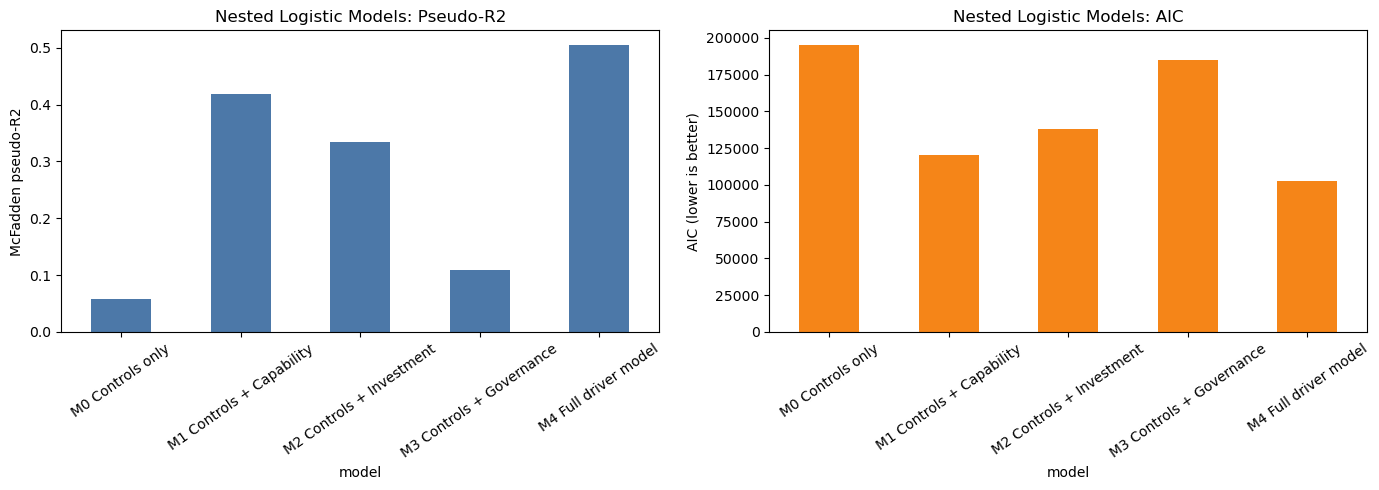

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_compare = logit_compare.set_index('model')
plot_compare['McFadden_pseudo_R2'].plot(kind='bar', ax=axes[0], color='#4c78a8')
axes[0].set_title('Nested Logistic Models: Pseudo-R2')
axes[0].set_ylabel('McFadden pseudo-R2')
axes[0].tick_params(axis='x', rotation=35)

plot_compare['AIC'].plot(kind='bar', ax=axes[1], color='#f58518')
axes[1].set_title('Nested Logistic Models: AIC')
axes[1].set_ylabel('AIC (lower is better)')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_05_logit_model_comparison.png', bbox_inches='tight')
plt.show()


**Q3 interpretation.** Capability adds the most explanatory power beyond controls (pseudo-R2 0.06 -> 0.42), followed by investment (-> 0.33); governance adds little (-> 0.11). In the full model the single strongest standardised driver is `ai_budget_percentage` (OR ~ 4.5), followed by `ai_training_hours` (OR ~ 3.6). The continuous governance scores are **not** independently associated with advanced adoption once capability and investment are included (`regulatory_compliance_score` OR ~ 1.0, p ~ 0.69; `ai_risk_management_score` OR ~ 0.99, p ~ 0.34); only the categorical ethics-committee indicator retains a modest association. Governance is therefore best described as a responsible-AI control rather than a predictor of progression. The model is association-only, not causal, and (per Section 3.2) the large effect sizes partly reflect the simulated data structure. Cluster-robust standard errors are used because firms appear repeatedly across quarters.
